In [4]:
import numpy
import pandas

personas = []

for i in range(100):

    edad = numpy.floor(numpy.random.normal(30, 15))

    if edad < 18:
        edad = 18
    if edad > 65:
        edad = 65

    hombre = numpy.random.choice([1, 0], p=[0.7, 0.3])
    salario = 0

    if hombre:
        salario = 8_000 + 15_000 * (1 - (edad - 18) / (65 - 18))
    else:
        salario = 8_000 + 7_000 * (1 - (edad - 18) / (65 - 18))

    personas.append({
        "edad": edad,
        "hombre": hombre,
        "salario": round(salario, 2),
    })

personas = pandas.DataFrame(personas)

personas

,edad,hombre,salario
0,51.0,0,10085.11
1,35.0,0,12468.09
2,65.0,1,8000.00
3,48.0,1,13425.53
4,50.0,1,12787.23
...,...,...,...
95,21.0,1,22042.55
96,43.0,1,15021.28
97,28.0,1,19808.51
98,40.0,1,15978.72


<Axes: ylabel='Density'>

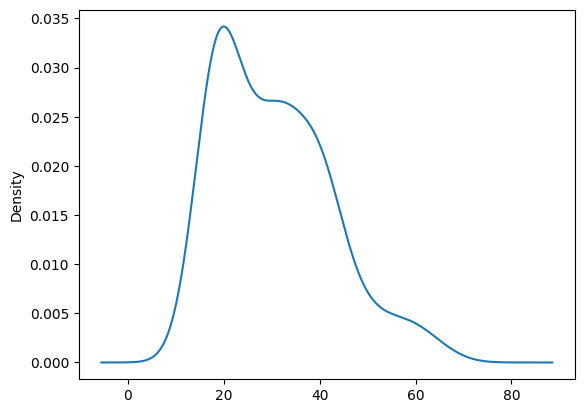

In [5]:
personas["edad"].plot.density()

<Axes: xlabel='edad', ylabel='Density'>

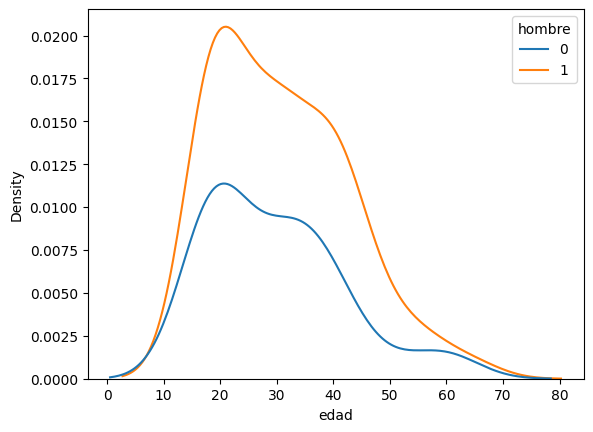

In [7]:
import seaborn

seaborn.kdeplot(personas, x="edad", hue="hombre")

In [8]:
personas.describe()

,edad,hombre,salario
count,100.000000,100.000000,100.000000
mean,30.520000,0.650000,16902.127500
std,11.722791,0.479372,4165.760737
min,18.000000,0.000000,8000.000000
25%,18.750000,0.000000,13845.747500
50%,29.000000,1.000000,15978.720000
75%,39.000000,1.000000,20526.597500
max,65.000000,1.000000,23000.000000


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(personas)

scaler.transform(personas)

array([[ 1.75582536, -1.36277029, -1.64468408],
       [ 0.3840868 , -1.36277029, -1.06976268],
       [ 2.9560966 ,  0.73379939, -2.14774091],
       [ 1.49862438,  0.73379939, -0.83876924],
       [ 1.6700917 ,  0.73379939, -0.99276647],
       [ 0.46982046,  0.73379939,  0.08521176],
       [ 0.21261948,  0.73379939,  0.31620762],
       [ 0.8127551 ,  0.73379939, -0.22278271],
       [-0.13031516, -1.36277029, -0.85416896],
       [-0.13031516,  0.73379939,  0.62419968],
       [-0.38751614,  0.73379939,  0.85519553],
       [ 0.21261948,  0.73379939,  0.31620762],
       [-1.07338543,  0.73379939,  1.47118206],
       [-1.07338543,  0.73379939,  1.47118206],
       [ 0.89848876,  0.73379939, -0.29978133],
       [ 0.21261948, -1.36277029, -0.99789811],
       [-0.0445815 , -1.36277029, -0.89010004],
       [ 0.46982046, -1.36277029, -1.10569617],
       [-1.07338543,  0.73379939,  1.47118206],
       [ 1.06995608,  0.73379939, -0.45377615],
       [ 0.04115216,  0.73379939,  0.470

In [12]:
personas_standard = scaler.transform(personas)

personas_standard = pandas.DataFrame(personas_standard, columns=["edad", "hombre", 'salario'])

personas_standard

,edad,hombre,salario
0,1.755825,-1.362770,-1.644684
1,0.384087,-1.362770,-1.069763
2,2.956097,0.733799,-2.147741
3,1.498624,0.733799,-0.838769
4,1.670092,0.733799,-0.992766
...,...,...,...
95,-0.816184,0.733799,1.240186
96,1.069956,0.733799,-0.453776
97,-0.216049,0.733799,0.701198
98,0.812755,0.733799,-0.222783


<Axes: xlabel='edad', ylabel='salario'>

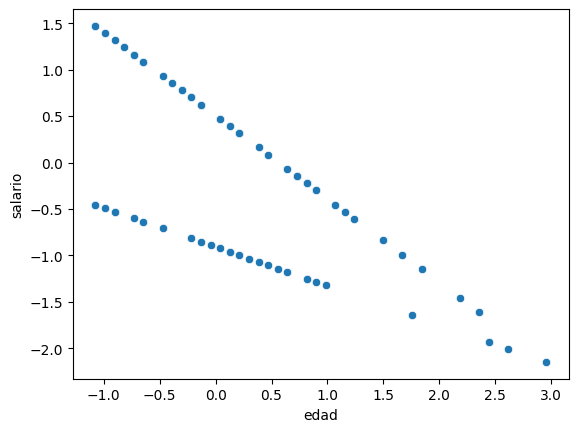

In [13]:
seaborn.scatterplot(x=personas_standard["edad"], y=personas_standard["salario"])

<Axes: xlabel='edad', ylabel='salario'>

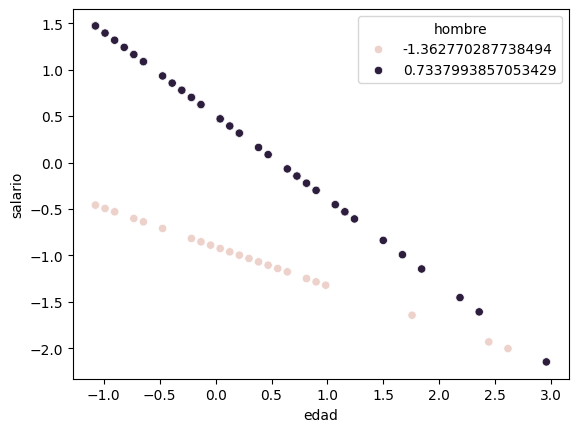

In [15]:
seaborn.scatterplot(x=personas_standard["edad"], y=personas_standard["salario"], hue=personas_standard["hombre"])

In [16]:
from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor()

reg.fit(personas_standard[["edad", "hombre"]], personas_standard["salario"])

salario_predict = reg.predict(personas_standard[["edad", "hombre"]])

pandas.DataFrame({
    "salario": personas_standard["salario"],
    "salario_predict": salario_predict,
})

,salario,salario_predict
0,-1.644684,-1.644684
1,-1.069763,-1.069763
2,-2.147741,-2.147741
3,-0.838769,-0.838769
4,-0.992766,-0.992766
...,...,...
95,1.240186,1.240186
96,-0.453776,-0.453776
97,0.701198,0.701198
98,-0.222783,-0.222783


<Axes: >

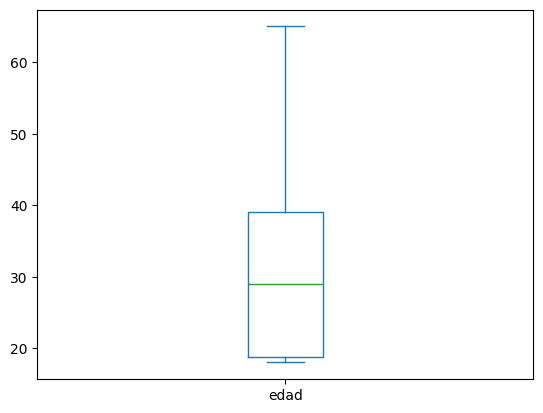

In [17]:
personas["edad"].plot.box()

<Axes: >

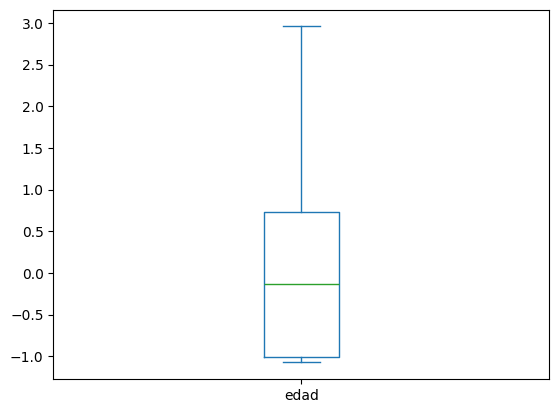

In [18]:
personas_standard["edad"].plot.box()